In [1]:
# 1. IMPORT LIBRARY UTAMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. LOAD DATASET
# (Pastikan letak file CSV sudah benar di folder 'dataset')
df = pd.read_csv('../dataset/predictive_maintenance.csv')

display(df.head())

print("=== Info Dataset ===")
df.info()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [2]:
# 3. PREPROCESSING (Revisi untuk XGBoost)
print("=== Memulai Preprocessing ===")

# Menghapus kolom yang tidak relevan
kolom_sampah = ['UDI', 'Product ID', 'Target']
df_bersih = df.drop(columns=kolom_sampah)

# 1. Mengubah kolom fitur 'Type' (L, M, H) menjadi angka (0, 1, 2)
le_type = LabelEncoder()
df_bersih['Type'] = le_type.fit_transform(df_bersih['Type'])

# 2. INI YANG BARU: Mengubah kolom Target 'Failure Type' menjadi angka (0 sampai 5)
le_target = LabelEncoder()
df_bersih['Failure Type'] = le_target.fit_transform(df_bersih['Failure Type'])

# Menentukan Fitur (X) dan Target (y)
X = df_bersih.drop(columns=['Failure Type'])
y = df_bersih['Failure Type']

print("Preprocessing Selesai! Target sudah diubah menjadi angka 0-5.")
display(df_bersih.head())

=== Memulai Preprocessing ===
Preprocessing Selesai! Target sudah diubah menjadi angka 0-5.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,2,298.1,308.6,1551,42.8,0,1
1,1,298.2,308.7,1408,46.3,3,1
2,1,298.1,308.5,1498,49.4,5,1
3,1,298.2,308.6,1433,39.5,7,1
4,1,298.2,308.7,1408,40.0,9,1


C:\Users\Hi\AppData\Local\Temp\ipykernel_18396\4268964062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Failure Type', data=df_bersih,


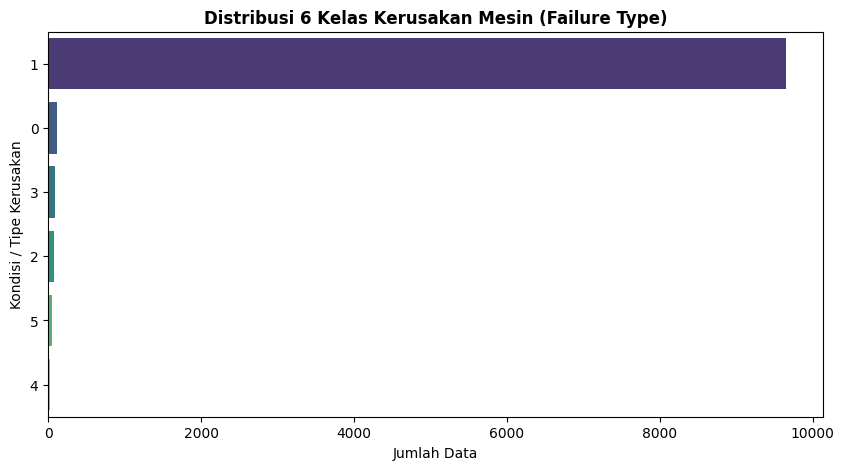

In [3]:
# 4. EDA: GRAFIK DISTRIBUSI KELAS
plt.figure(figsize=(10, 5))
sns.countplot(y='Failure Type', data=df_bersih, 
              order=df_bersih['Failure Type'].value_counts().index, 
              palette='viridis')

plt.title('Distribusi 6 Kelas Kerusakan Mesin (Failure Type)', fontweight='bold')
plt.xlabel('Jumlah Data')
plt.ylabel('Kondisi / Tipe Kerusakan')
plt.show()

In [4]:
# 5. DATA SPLITTING (Versi Bersih untuk Model Tree-Based)
data_splits = {}
ratios = {'70:30': 0.3, '80:20': 0.2, '90:10': 0.1}

print("=== PROSES PEMBAGIAN DATA ===")
for nama_rasio, test_size in ratios.items():
    # Belah data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Langsung simpan ke dictionary (Tanpa Scaler!)
    data_splits[nama_rasio] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test
    }
    print(f"Rasio {nama_rasio} berhasil disiapkan!")

=== PROSES PEMBAGIAN DATA ===
Rasio 70:30 berhasil disiapkan!
Rasio 80:20 berhasil disiapkan!
Rasio 90:10 berhasil disiapkan!


In [5]:
# 6. PELATIHAN & EVALUASI MODEL MODERN (9 OUTPUT)
models = {
    "XGBoost Classifier": XGBClassifier(
        random_state=42, 
        eval_metric='mlogloss'
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        class_weight='balanced', 
        max_iter=200 
    ),
    "Extra Trees Classifier": ExtraTreesClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=100
    )
}

hasil_eksperimen = []
print("=== MEMULAI PELATIHAN TRIO ENSEMBLE MODERN ===")

for nama_rasio, data in data_splits.items():
    print(f"🔄 Memproses Rasio {nama_rasio}...")
    
    for nama_model, model in models.items():
        # Training
        model.fit(data['X_train'], data['y_train'])
        
        # Prediksi
        y_pred = model.predict(data['X_test'])
        
        # Evaluasi (Weighted untuk Multikelas)
        akurasi = accuracy_score(data['y_test'], y_pred)
        presisi = precision_score(data['y_test'], y_pred, average='weighted', zero_division=0)
        recall = recall_score(data['y_test'], y_pred, average='weighted', zero_division=0)
        f1 = f1_score(data['y_test'], y_pred, average='weighted', zero_division=0)
        
        # Simpan hasil
        hasil_eksperimen.append({
            'Rasio Data': nama_rasio,
            'Algoritma': nama_model,
            'Accuracy': akurasi * 100,
            'Precision': presisi * 100,
            'Recall': recall * 100,
            'F1-Score': f1 * 100
        })

print("\n✅ Pelatihan selesai!")

=== MEMULAI PELATIHAN TRIO ENSEMBLE MODERN ===
🔄 Memproses Rasio 70:30...


ValueError: feature_names must be string, and may not contain [, ] or <

=== TABEL EVALUASI LENGKAP (Accuracy, Precision, Recall, F1-Score) ===


,Rasio Data,Algoritma,Accuracy,Precision,Recall,F1-Score
0,90:10,HistGradientBoosting,98.40,98.09,98.40,98.22
1,90:10,XGBoost Classifier,98.20,97.42,98.20,97.78
2,90:10,Extra Trees Classifier,97.40,97.25,97.40,96.64
3,80:20,HistGradientBoosting,98.30,97.89,98.30,98.08
4,80:20,XGBoost Classifier,98.25,97.44,98.25,97.81
5,80:20,Extra Trees Classifier,97.50,97.13,97.50,96.70
6,70:30,HistGradientBoosting,98.47,98.11,98.47,98.28
7,70:30,XGBoost Classifier,98.33,97.81,98.33,98.04
8,70:30,Extra Trees Classifier,97.70,97.44,97.70,97.02


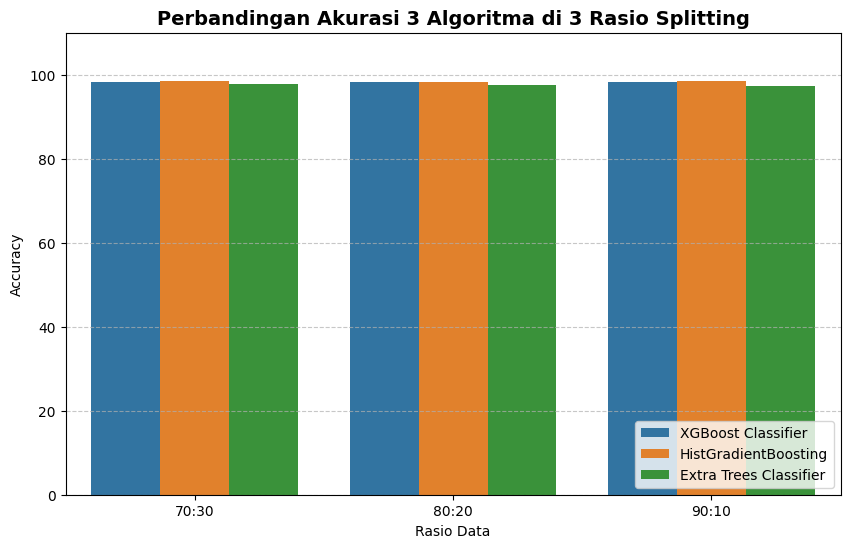

In [ ]:
# 7. MENAMPILKAN TABEL HASIL EVALUASI LENGKAP
df_hasil = pd.DataFrame(hasil_eksperimen)

print("=== TABEL EVALUASI LENGKAP (Accuracy, Precision, Recall, F1-Score) ===")
# Menampilkan tabel utuh agar semua metrik terlihat
display(df_hasil.round(2).sort_values(by=['Rasio Data', 'Accuracy'], ascending=[False, False]).reset_index(drop=True))

# Visualisasi Bar Chart khusus untuk Accuracy sebagai perbandingan utama
plt.figure(figsize=(10, 6))
sns.barplot(data=df_hasil, x='Rasio Data', y='Accuracy', hue='Algoritma')

plt.title('Perbandingan Akurasi 3 Algoritma di 3 Rasio Splitting', fontsize=14, fontweight='bold')
plt.ylim(0, 110)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 8. SIMULASI PENGUJIAN DATA BARU (INFERENCE)
print("=== SIMULASI DETEKSI KERUSAKAN MESIN ===")

# 1. Kita buat "Model Final" (Latih pakai SEMUA data agar AI paling cerdas)
# Kita pakai XGBoost karena biasanya dia yang paling jago
scaler_final = StandardScaler()
X_scaled_full = scaler_final.fit_transform(X) # Variabel X ada dari Cell 2

model_final = XGBClassifier(random_state=42, eval_metric='mlogloss')
model_final.fit(X_scaled_full, y) # Variabel y ada dari Cell 2

# 2. INPUT DATA SENSOR BARU (Silakan ganti-ganti angkanya di sini!)
# Keterangan Tipe (Type): 0 = L (Low), 1 = M (Medium), 2 = H (High)
data_baru = pd.DataFrame({
    'Type': [1],                        # Kualitas alat (Contoh: 0)
    'Air temperature [K]': [298.1],     # Suhu ruangan (Kelvin)
    'Process temperature [K]': [308.6], # Suhu internal mesin (Kelvin)
    'Rotational speed [rpm]': [1551],   # Putaran mesin (Makin rendah saat overheat)
    'Torque [Nm]': [42.8],              # Tarikan/Beban (Makin tinggi makin berat)
    'Tool wear [min]': [0]            # Lama pemakaian alat dalam menit
})

print("📡 Membaca Data Sensor Masuk:")
display(data_baru)

# 3. STANDARISASI INPUT
# PENTING: Data baru wajib di-scaling pakai 'scaler_final' agar AI tidak bingung
data_baru_scaled = scaler_final.transform(data_baru)

# 4. AI MELAKUKAN PREDIKSI
hasil_prediksi_angka = model_final.predict(data_baru_scaled)

# 5. Menerjemahkan angka tebakan AI kembali ke teks asli (No Failure, Overheat, dll)
# Kita pakai le_target yang sudah kita buat di Cell 2
hasil_teks = le_target.inverse_transform(hasil_prediksi_angka)

print("\n🚨 HASIL ANALISIS AI 🚨")
print(f"Status Mesin Saat Ini : >> {hasil_teks[0].upper()} <<")

=== SIMULASI DETEKSI KERUSAKAN MESIN ===
📡 Membaca Data Sensor Masuk:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,298.1,308.6,1551,42.8,0



🚨 HASIL ANALISIS AI 🚨
Status Mesin Saat Ini : >> NO FAILURE <<
